In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Cell 2 — Define project paths

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "online_retail_II.xlsx"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", RAW_DATA_PATH)
print("Dataset exists:", RAW_DATA_PATH.exists())

Project root: C:\Users\arman\OneDrive\Desktop\Data_Analyst\Projects\CustomerIQ_Unsupervised\CustomerIQ
Dataset path: C:\Users\arman\OneDrive\Desktop\Data_Analyst\Projects\CustomerIQ_Unsupervised\CustomerIQ\data\raw\online_retail_II.xlsx
Dataset exists: True


In [3]:
# Step 3 — Load both sheets

excel_file = pd.ExcelFile(RAW_DATA_PATH)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [4]:
df_2009_2010 = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name="Year 2010-2011"
)

In [5]:
print("2009-2010:", df_2009_2010.shape)
print("2010-2011:", df_2010_2011.shape)

2009-2010: (525461, 8)
2010-2011: (541910, 8)


In [6]:
# Step 4 — Combine the datasets
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Combined shape:", df.shape)

Combined shape: (1067371, 8)


In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [8]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,"12,680.00",France


In [9]:
# Step 6 — Column names
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [10]:
# Step 7 — Missing values
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing["missing_percentage"] = (
    missing["missing_count"] / len(df) * 100
)

missing.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [11]:
# Step 8 — Duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    duplicate_count / len(df) * 100
)

Duplicate rows: 34335
Duplicate percentage: 3.2167821685243467


In [12]:
# Step 9 — Transaction cancellations
df["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
False    1047877
True       19494
Name: count, dtype: int64

In [13]:
cancelled = df[
    df["Invoice"].astype(str).str.startswith("C")
]

cancelled.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia


In [14]:
print("Cancelled rows:", len(cancelled))

Cancelled rows: 19494


In [15]:
# Step 10 — Quantity anomalies
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Zero quantity:", (df["Quantity"] == 0).sum())
print("Positive quantity:", (df["Quantity"] > 0).sum())

Negative quantity: 22950
Zero quantity: 0
Positive quantity: 1044421


In [16]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,"16,321.00",Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,"17,592.00",United Kingdom


In [17]:
# Step 11 — Price anomalies
print("Negative price:", (df["Price"] < 0).sum())
print("Zero price:", (df["Price"] == 0).sum())
print("Positive price:", (df["Price"] > 0).sum())

Negative price: 5
Zero price: 6202
Positive price: 1061164


In [18]:
df[df["Price"] == 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom


In [19]:
# Step 12 — Date range
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

In [20]:
print("Minimum date:", df["InvoiceDate"].min())
print("Maximum date:", df["InvoiceDate"].max())

Minimum date: 2009-12-01 07:45:00
Maximum date: 2011-12-09 12:50:00


In [21]:
print("Invalid dates:", df["InvoiceDate"].isna().sum())

Invalid dates: 0


In [24]:
# Step 13 — Customer statistics
print("Unique customers:", df["Customer ID"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique countries:", df["Country"].nunique())
print("Unique invoices:", df["Invoice"].nunique())

Unique customers: 5942
Unique products: 5305
Unique countries: 43
Unique invoices: 53628


In [25]:
# Step 14 — Basic transaction statistics
print("Total rows:", len(df))
print("Total invoices:", df["Invoice"].nunique())
print("Total customers:", df["Customer ID"].nunique())
print("Total products:", df["StockCode"].nunique())
print("Total countries:", df["Country"].nunique())

Total rows: 1067371
Total invoices: 53628
Total customers: 5942
Total products: 5305
Total countries: 43


In [26]:
# Step 15 — Country distribution
country_distribution = (
    df["Country"]
    .value_counts()
    .head(15)
)

country_distribution

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Name: count, dtype: int64

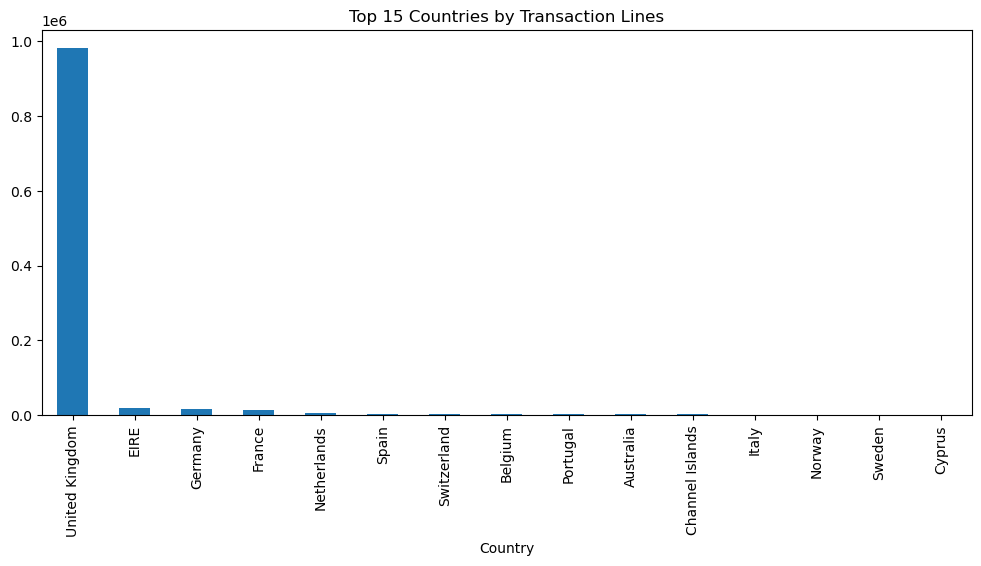

In [27]:
country_distribution.plot(
    kind="bar",
    figsize=(12, 5),
    title="Top 15 Countries by Transaction Lines"
);

In [28]:
# Step 16 — Create a data-quality summary
data_quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().sum() / len(df) * 100
    ),
    "unique_values": df.nunique()
})

data_quality

,dtype,missing_count,missing_percentage,unique_values
Invoice,object,0,0.00,53628
StockCode,object,0,0.00,5305
Description,object,4382,0.41,5698
Quantity,int64,0,0.00,1057
InvoiceDate,datetime64[ns],0,0.00,47635
Price,float64,0,0.00,2807
Customer ID,float64,243007,22.77,5942
Country,object,0,0.00,43


In [29]:
data_quality.sort_values(
    "missing_percentage",
    ascending=False
)

,dtype,missing_count,missing_percentage,unique_values
Customer ID,float64,243007,22.77,5942
Description,object,4382,0.41,5698
Invoice,object,0,0.00,53628
StockCode,object,0,0.00,5305
Quantity,int64,0,0.00,1057
InvoiceDate,datetime64[ns],0,0.00,47635
Price,float64,0,0.00,2807
Country,object,0,0.00,43


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [31]:
# A. Missing Customer ID impact
missing_customer = df["Customer ID"].isna()

print("Rows with missing Customer ID:", missing_customer.sum())
print(
    "Percentage:",
    missing_customer.mean() * 100
)

print(
    "Invoices affected:",
    df.loc[missing_customer, "Invoice"].nunique()
)

print(
    "Products involved:",
    df.loc[missing_customer, "StockCode"].nunique()
)

Rows with missing Customer ID: 243007
Percentage: 22.766872999172733
Invoices affected: 8752
Products involved: 5177


In [32]:
df["LineTotal"] = df["Quantity"] * df["Price"]

In [33]:
missing_customer_value = df.loc[
    missing_customer,
    "LineTotal"
].sum()

total_value = df["LineTotal"].sum()

print("Value associated with missing Customer ID:", missing_customer_value)
print("Total transaction-line value:", total_value)
print(
    "Percentage of value:",
    missing_customer_value / total_value * 100
)

Value associated with missing Customer ID: 2638958.18
Total transaction-line value: 19287250.56799999
Percentage of value: 13.682396932087194


In [34]:
# B. Missing Customer ID by country
missing_customer_country = (
    df.loc[missing_customer]
      .groupby("Country")
      .size()
      .sort_values(ascending=False)
      .head(15)
)

missing_customer_country

Country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
RSA                         46
Bermuda                     34
Sweden                      19
Lebanon                     13
Nigeria                      2
dtype: int64

In [35]:
df.groupby("Country")["Customer ID"].apply(
    lambda x: x.isna().mean() * 100
).sort_values(ascending=False).head(15)

Country
Hong Kong              100.00
Bermuda                100.00
Bahrain                 53.17
Unspecified             30.69
RSA                     27.22
United Kingdom          24.46
United Arab Emirates    22.80
Lebanon                 22.41
Israel                  12.67
EIRE                     9.35
Nigeria                  6.25
Portugal                 4.43
Switzerland              3.92
Sweden                   1.39
France                   0.89
Name: Customer ID, dtype: float64

In [36]:
# C. Duplicate investigation
duplicates = df[df.duplicated(keep=False)].sort_values(
    ["Invoice", "StockCode", "InvoiceDate"]
)

duplicates.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,LineTotal
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,1.95
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,1.95
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,5.10


In [37]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Duplicate rows:", len(duplicate_rows))
print(
    "Duplicate invoices:",
    duplicate_rows["Invoice"].nunique()
)

Duplicate rows: 67242
Duplicate invoices: 5391


In [38]:
duplicate_invoice_counts = (
    duplicate_rows
    .groupby("Invoice")
    .size()
    .sort_values(ascending=False)
)

duplicate_invoice_counts.head(20)

Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
536592    1184
537823    1182
537240    1136
537666    1072
536544    1054
537224     338
537781     322
537640     298
536982     290
536865     280
537643     246
537642     244
536796     242
538153     242
537126     236
dtype: int64

In [39]:
# D. Cancellation relationship
df["IsCancelled"] = (
    df["Invoice"]
    .astype(str)
    .str.startswith("C")
)

In [40]:
pd.crosstab(
    df["IsCancelled"],
    df["Quantity"] < 0,
    rownames=["Cancelled Invoice"],
    colnames=["Negative Quantity"]
)

Negative Quantity,False,True
Cancelled Invoice,,
False,1044420,3457
True,1,19493


In [41]:
print(
    "Cancelled invoices with negative quantity:",
    df.loc[
        df["IsCancelled"] & (df["Quantity"] < 0),
        "Invoice"
    ].nunique()
)

print(
    "Negative quantity rows NOT marked as cancellation:",
    (
        (~df["IsCancelled"]) &
        (df["Quantity"] < 0)
    ).sum()
)

Cancelled invoices with negative quantity: 8291
Negative quantity rows NOT marked as cancellation: 3457


In [42]:
# E. Negative price investigation
df[df["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,LineTotal,IsCancelled
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.36",NaN,United Kingdom,"-53,594.36",False
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.79",NaN,United Kingdom,"-44,031.79",False
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.87",NaN,United Kingdom,"-38,925.87",False
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom,"-11,062.06",False
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom,"-11,062.06",False


In [43]:
# F. Zero-price investigation
zero_price = df[df["Price"] == 0]

print("Zero-price rows:", len(zero_price))
print(
    "Zero-price invoices:",
    zero_price["Invoice"].nunique()
)
print(
    "Zero-price products:",
    zero_price["StockCode"].nunique()
)

Zero-price rows: 6202
Zero-price invoices: 5379
Zero-price products: 2971


In [44]:
zero_price.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,LineTotal,IsCancelled
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,-0.00,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,-0.00,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,-0.00,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,-0.00,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,-0.00,False
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom,0.00,False
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom,-0.00,False
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom,-0.00,False
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom,0.00,False
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,-0.00,False


In [45]:
zero_price["Description"].value_counts().head(20)

Description
check                            162
?                                 92
damages                           84
damaged                           81
found                             28
missing                           27
sold as set on dotcom             20
Damaged                           17
adjustment                        16
OWL DOORSTOP                      15
dotcom                            12
POLYESTER FILLER PAD 45x45cm      12
amazon                            11
FRENCH BLUE METAL DOOR SIGN 1     10
IVORY KITCHEN SCALES              10
POLYESTER FILLER PAD 40x40cm      10
FRENCH BLUE METAL DOOR SIGN 8      9
thrown away                        9
Found                              9
PICNIC BASKET WICKER LARGE         9
Name: count, dtype: int64

In [46]:
# G. Customer activity distribution
customer_transactions = df[
    df["Customer ID"].notna()
]

In [47]:
customer_activity = (
    customer_transactions
    .groupby("Customer ID")
    .agg(
        transaction_lines=("Invoice", "size"),
        invoices=("Invoice", "nunique"),
        products=("StockCode", "nunique"),
        total_quantity=("Quantity", "sum"),
        total_value=("LineTotal", "sum")
    )
)

In [48]:
customer_activity.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_lines,"5,942.00",138.74,359.69,1.00,21.00,53.00,144.00,"13,097.00"
invoices,"5,942.00",7.55,15.97,1.00,2.00,4.00,8.00,510.00
products,"5,942.00",81.32,116.40,1.00,18.00,44.00,102.00,"2,557.00"
total_quantity,"5,942.00","1,722.34","8,563.25","-1,085.00",180.00,474.00,"1,340.75","365,220.00"
total_value,"5,942.00","2,801.80","13,973.92","-25,111.09",325.10,843.97,"2,182.01","598,215.22"


In [49]:
customer_activity.sort_values(
    "total_value",
    ascending=False
).head(20)

,transaction_lines,invoices,products,total_quantity,total_value
Customer ID,,,,,
"18,102.00",1068,153,384,187110,"598,215.22"
"14,646.00",3890,164,964,365220,"523,342.07"
"14,156.00",4130,202,1446,163910,"296,564.69"
"14,911.00",11613,510,2557,143741,"270,248.53"
"17,450.00",448,61,148,81644,"233,579.39"
"13,694.00",1558,164,902,185442,"190,825.52"
"17,511.00",2134,85,678,117913,"171,885.98"
"12,415.00",990,33,498,91315,"143,269.29"
"16,684.00",749,65,186,101095,"141,502.25"


In [50]:
# 1. Missing Customer ID impact
print("Rows:", missing_customer.sum())
print("Percentage:", missing_customer.mean() * 100)
print("Invoices:", df.loc[missing_customer, "Invoice"].nunique())
print("Products:", df.loc[missing_customer, "StockCode"].nunique())

print("Missing Customer Value:", missing_customer_value)
print("Total Value:", total_value)
print("Value Percentage:", missing_customer_value / total_value * 100)

Rows: 243007
Percentage: 22.766872999172733
Invoices: 8752
Products: 5177
Missing Customer Value: 2638958.18
Total Value: 19287250.56799999
Value Percentage: 13.682396932087194


In [51]:
# 2. Missing Customer ID by country
missing_customer_country.head(10)

Country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
dtype: int64

In [52]:
df.groupby("Country")["Customer ID"].apply(
    lambda x: x.isna().mean() * 100
).sort_values(ascending=False).head(10)

Country
Hong Kong              100.00
Bermuda                100.00
Bahrain                 53.17
Unspecified             30.69
RSA                     27.22
United Kingdom          24.46
United Arab Emirates    22.80
Lebanon                 22.41
Israel                  12.67
EIRE                     9.35
Name: Customer ID, dtype: float64

In [53]:
# 3. Duplicate investigation
print("Duplicate rows:", len(duplicate_rows))
print("Duplicate invoices:", duplicate_rows["Invoice"].nunique())

Duplicate rows: 67242
Duplicate invoices: 5391


In [54]:
duplicates.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,LineTotal
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,1.95
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,1.95
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,5.10


In [55]:
# 4. Cancellation vs negative quantity
pd.crosstab(
    df["IsCancelled"],
    df["Quantity"] < 0,
    rownames=["Cancelled Invoice"],
    colnames=["Negative Quantity"]
)

Negative Quantity,False,True
Cancelled Invoice,,
False,1044420,3457
True,1,19493


In [56]:
print(
    "Cancelled invoices with negative quantity:",
    df.loc[
        df["IsCancelled"] & (df["Quantity"] < 0),
        "Invoice"
    ].nunique()
)

print(
    "Negative quantity rows NOT marked as cancellation:",
    (
        (~df["IsCancelled"]) &
        (df["Quantity"] < 0)
    ).sum()
)

Cancelled invoices with negative quantity: 8291
Negative quantity rows NOT marked as cancellation: 3457


In [57]:
# 5. Negative prices
df[df["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,LineTotal,IsCancelled
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.36",NaN,United Kingdom,"-53,594.36",False
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.79",NaN,United Kingdom,"-44,031.79",False
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.87",NaN,United Kingdom,"-38,925.87",False
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom,"-11,062.06",False
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom,"-11,062.06",False


In [58]:
# 6. Zero-price transactions
print("Zero-price rows:", len(zero_price))
print("Zero-price invoices:", zero_price["Invoice"].nunique())
print("Zero-price products:", zero_price["StockCode"].nunique())

Zero-price rows: 6202
Zero-price invoices: 5379
Zero-price products: 2971


In [59]:
zero_price["Description"].value_counts().head(10)

Description
check                    162
?                         92
damages                   84
damaged                   81
found                     28
missing                   27
sold as set on dotcom     20
Damaged                   17
adjustment                16
OWL DOORSTOP              15
Name: count, dtype: int64

In [60]:
# 7. Customer activity
customer_activity.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_lines,"5,942.00",138.74,359.69,1.00,21.00,53.00,144.00,"13,097.00"
invoices,"5,942.00",7.55,15.97,1.00,2.00,4.00,8.00,510.00
products,"5,942.00",81.32,116.40,1.00,18.00,44.00,102.00,"2,557.00"
total_quantity,"5,942.00","1,722.34","8,563.25","-1,085.00",180.00,474.00,"1,340.75","365,220.00"
total_value,"5,942.00","2,801.80","13,973.92","-25,111.09",325.10,843.97,"2,182.01","598,215.22"


In [61]:
customer_activity.sort_values(
    "total_value",
    ascending=False
).head(10)

,transaction_lines,invoices,products,total_quantity,total_value
Customer ID,,,,,
"18,102.00",1068,153,384,187110,"598,215.22"
"14,646.00",3890,164,964,365220,"523,342.07"
"14,156.00",4130,202,1446,163910,"296,564.69"
"14,911.00",11613,510,2557,143741,"270,248.53"
"17,450.00",448,61,148,81644,"233,579.39"
"13,694.00",1558,164,902,185442,"190,825.52"
"17,511.00",2134,85,678,117913,"171,885.98"
"12,415.00",990,33,498,91315,"143,269.29"
"16,684.00",749,65,186,101095,"141,502.25"


## Data Cleaning

In [62]:
# 1. Start from the combined raw dataframe
df_clean = df.copy()

In [63]:
# 2. Remove exact duplicates
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 1067371
Rows after: 1033036
Rows removed: 34335


In [64]:
# 3. Create transaction flags
df_clean["IsCancelled"] = (
    df_clean["Invoice"]
    .astype(str)
    .str.startswith("C")
)

df_clean["IsReturn"] = df_clean["Quantity"] < 0

In [65]:
# 4. Create transaction value
df_clean["LineTotal"] = (
    df_clean["Quantity"] * df_clean["Price"]
)

In [66]:
# 5. Create the returns dataset
returns_df = df_clean[
    df_clean["Quantity"] < 0
].copy()

In [67]:
print("Return rows:", len(returns_df))
print(
    "Customers with returns:",
    returns_df["Customer ID"].nunique()
)

Return rows: 22496
Customers with returns: 2572


In [68]:
returns_df["ReturnValue"] = (
    returns_df["Quantity"] *
    returns_df["Price"]
).abs()

In [70]:
# 6. Create valid sales dataset
sales_df = df_clean[
    (~df_clean["IsCancelled"]) &
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

In [71]:
# 7. Remove missing Customer IDs from customer analytics
customer_sales = sales_df[
    sales_df["Customer ID"].notna()
].copy()

In [72]:
print("Customer sales rows:", len(customer_sales))
print(
    "Unique customers:",
    customer_sales["Customer ID"].nunique()
)

Customer sales rows: 779425
Unique customers: 5878


In [73]:
# 8. Recalculate revenue
customer_sales["Revenue"] = (
    customer_sales["Quantity"] *
    customer_sales["Price"]
)

In [74]:
print(
    "Clean sales revenue:",
    customer_sales["Revenue"].sum()
)

Clean sales revenue: 17374804.268000003


In [75]:
# 9. Validate the cleaned dataset
print("Rows:", len(customer_sales))
print(
    "Customers:",
    customer_sales["Customer ID"].nunique()
)
print(
    "Invoices:",
    customer_sales["Invoice"].nunique()
)
print(
    "Products:",
    customer_sales["StockCode"].nunique()
)
print(
    "Countries:",
    customer_sales["Country"].nunique()
)

Rows: 779425
Customers: 5878
Invoices: 36969
Products: 4631
Countries: 41


In [76]:
print(
    "Negative quantity:",
    (customer_sales["Quantity"] < 0).sum()
)

print(
    "Zero quantity:",
    (customer_sales["Quantity"] == 0).sum()
)

print(
    "Negative price:",
    (customer_sales["Price"] < 0).sum()
)

print(
    "Zero price:",
    (customer_sales["Price"] == 0).sum()
)

print(
    "Missing Customer ID:",
    customer_sales["Customer ID"].isna().sum()
)

Negative quantity: 0
Zero quantity: 0
Negative price: 0
Zero price: 0
Missing Customer ID: 0


In [78]:
# Normalize identifier columns before saving to Parquet
customer_sales["Invoice"] = customer_sales["Invoice"].astype("string")
customer_sales["StockCode"] = customer_sales["StockCode"].astype("string")
customer_sales["Description"] = customer_sales["Description"].astype("string")
customer_sales["Country"] = customer_sales["Country"].astype("string")

In [79]:
customer_sales["Customer ID"] = (
    customer_sales["Customer ID"]
    .astype("int64")
)

In [80]:
customer_sales.dtypes

Invoice        string[python]
StockCode      string[python]
Description    string[python]
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country        string[python]
LineTotal             float64
IsCancelled              bool
IsReturn                 bool
Revenue               float64
dtype: object

In [81]:
# 10. Save the cleaned transaction data
PROCESSED_DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "customer_sales.parquet"
)

PROCESSED_DATA_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

customer_sales.to_parquet(
    PROCESSED_DATA_PATH,
    index=False
)

print(PROCESSED_DATA_PATH)

C:\Users\arman\OneDrive\Desktop\Data_Analyst\Projects\CustomerIQ_Unsupervised\CustomerIQ\data\processed\customer_sales.parquet
